## Feature Engineering for Machine Learning

**Feature Engineering** is the process of selecting, transforming, and combining raw data into meaningful features (variables) that a machine learning model can understand and use effectively.

#### Why it is Essential:
1. **Bridges the Gap Between Text and Math**: Machine learning algorithms (especially deep learning models like neural networks) cannot process raw text directly. They require numeric inputs. Converting text to features like multi-hot vectors or numerical matrices allows models to compute patterns.
2. **Improves Model Accuracy**: Providing well-structured features makes it easier for the algorithm to find relationships and make correct predictions, rather than forcing the model to find patterns in noisy raw text.
3. **Reduces Complexity**: By selecting and isolating key information (such as specific tools and skills), we focus the model's capacity on the most predictive components, leading to faster training times and lower risk of overfitting.

In [11]:
import pandas as pd

df = pd.read_csv("job_description.csv")

# Print the first 20 lines
df.head(20)

,Job Title,Description
0,Data Analyst,job overview were seeking a data analyst to tu...
1,Data Reporting Analyst,about wspc wspc is a cooperative of outstandin...
2,Data Analyst (Power BI/Python),data analyst power bipython employment type fu...
3,Data & Reporting Analyst,our company pharmerica overview the data repor...
4,Data Quality Analyst (Remote Opportunity),vetsez is seeking a data quality analyst teste...
5,Data Analyst,"synergy family services, inc. sfs is a dynamic..."
6,"Data Reporting Analyst- (***YORK, PA***)",eastern lift truck co. data reporting analystr...
7,Product Data Analyst,who we are addepar is a global technology and ...
8,Technical Data Analyst,"role technical data analyst location mclean, v..."
9,Data Integration Analyst,location remote u.s. based employment type ful...


In [12]:
# Get all unique jobs
df['Job Title'].unique()

array(['Data Analyst', 'Data Reporting Analyst',
       'Data Analyst (Power BI/Python)', 'Data & Reporting Analyst',
       'Data Quality Analyst (Remote Opportunity)',
       'Data Reporting Analyst- (***YORK, PA***)', 'Product Data Analyst',
       'Technical Data Analyst', 'Data Integration Analyst',
       'Business Data Analyst', 'Data Analyst I',
       'Data Scientist / Analyst, Junior - FAA',
       'Data Governance Analyst', 'PowerBI Data Analyst',
       'Data Analyst, Field Planning & Analytics',
       'Data Intelligence / PowerBI Analyst',
       'Sr. Analyst, Analytics & Data Products',
       'Content and Data Analyst', 'Junior Data Analyst',
       'ERP Data Analyst- NEW', 'Entry Level Business Analyst',
       'Data Analyst, Tableau Developer',
       'Tableau Data Analyst -100% Remote', 'Contract Data Analyst',
       'Insurance Data Analyst', 'GLO - Data Analyst (DRGR Specialist)',
       'Data Analyst (Finance)', 'ISRM Data & Analytics GEM Fellow 2025',
       'Mar

In [13]:
# Count how many Data Analyst jobs are there
print("Data Analyst Jobs:", len(df[df['Job Title'].str.contains('Data Analyst')]))

Data Analyst Jobs: 290


### NLP Libraries for Skill Extraction

For extracting skills from unstructured job descriptions to prepare training data, the most recommended Python libraries are:

* **spaCy**: Offers high-performance tokenization, POS tagging, and Named Entity Recognition (NER). We can use spaCy's rule-based matcher (`EntityRuler`) to bootstrap skill extraction or train a custom transition-based NER parser.
* **Hugging Face Transformers**: Allows the use of transformer models (like RoBERTa or specialized JobBERT models) to perform zero-shot extraction or fine-tune a model specifically for skill extraction.
* **KeyBERT**: A minimal and easy-to-use keyword extraction technique that leverages BERT embeddings to find sub-phrases most similar to a document.

Demonstration using **spaCy** to parse job descriptions and extract some sample skills.

In [14]:
import spacy
from spacy.pipeline import EntityRuler

# Load a small English pipeline
nlp = spacy.load("en_core_web_sm")

# Define a sample list of skills we want to extract to demonstrate the rule-based approach
skills_list = ["python", "power bi", "sql", "tableau", "excel", "analytics", "machine learning", "data quality"]

# Set up an EntityRuler to match these skills
ruler = nlp.add_pipe("entity_ruler", before="ner")
patterns = [{"label": "SKILL", "pattern": [{"LOWER": token.lower()} for token in skill.split()]} for skill in skills_list]
ruler.add_patterns(patterns)

# Let's test extraction on the first few job descriptions
def extract_skills(text):
    if not isinstance(text, str):
        return []
    doc = nlp(text)
    # Extract entities marked as SKILL
    skills = [ent.text.lower() for ent in doc.ents if ent.label_ == "SKILL"]
    return list(set(skills))

# Extract skills for the first 10 rows
df_sample = df.head(10).copy()
df_sample['Extracted Skills'] = df_sample['Description'].apply(extract_skills)
display(df_sample[['Job Title', 'Extracted Skills']])

,Job Title,Extracted Skills
0,Data Analyst,"[python, power bi, sql, excel, tableau]"
1,Data Reporting Analyst,"[python, power bi, sql, excel, tableau, data q..."
2,Data Analyst (Power BI/Python),"[python, sql, excel]"
3,Data & Reporting Analyst,"[power bi, sql, analytics, excel]"
4,Data Quality Analyst (Remote Opportunity),"[power bi, data quality, sql]"
5,Data Analyst,[]
6,"Data Reporting Analyst- (***YORK, PA***)","[power bi, analytics, excel]"
7,Product Data Analyst,"[python, power bi, analytics, sql, tableau]"
8,Technical Data Analyst,"[python, sql, analytics]"
9,Data Integration Analyst,"[data quality, sql, analytics]"


### Feature Engineering: Multi-Hot Encoding & Label Encoding

To train a neural network, we will:
1. Apply our skill extraction function to the entire dataset.
2. Perform **multi-hot encoding** on the extracted skills to construct our feature matrix ($X$).
3. Simplify the job titles into categorized labels and encode them ($y$).

In [15]:
import numpy as np
from sklearn.preprocessing import MultiLabelBinarizer

# 1. Extract skills for the entire dataset
df['Extracted Skills'] = df['Description'].apply(extract_skills)

# 2. Multi-hot encode the skills using MultiLabelBinarizer
mlb = MultiLabelBinarizer(classes=skills_list)
X = mlb.fit_transform(df['Extracted Skills'])

# 3. Categorize job titles into simplified target labels
def categorize_title(title):
    if not isinstance(title, str):
        return 0 # Other
    title_lower = title.lower()
    if 'quality' in title_lower or 'governance' in title_lower:
        return 1 # Quality & Governance
    elif 'reporting' in title_lower or 'powerbi' in title_lower or 'tableau' in title_lower or 'visualization' in title_lower:
        return 2 # Reporting & BI
    elif 'data analyst' in title_lower:
        return 3 # Core Data Analyst
    else:
        return 0 # Other / General

df['Label'] = df['Job Title'].apply(categorize_title)
y = df['Label'].values

# Display shape and sample arrays
print("Feature matrix shape (X):", X.shape)
print("Label vector shape (y):", y.shape)
print("\nFirst 5 multi-hot encoded skill rows:\n", X[:5])
print("\nFirst 5 labels:\n", y[:5])

Feature matrix shape (X): (521, 8)
Label vector shape (y): (521,)

First 5 multi-hot encoded skill rows:
 [[1 1 1 1 1 0 0 0]
 [1 1 1 1 1 0 0 1]
 [1 0 1 0 1 0 0 0]
 [0 1 1 0 1 1 0 0]
 [0 1 1 0 0 0 0 1]]

First 5 labels:
 [3 2 3 2 1]


### Building and Training the TensorFlow Model

We will construct a simple feedforward neural network in TensorFlow to classify the job category based on the extracted multi-hot encoded skills.

In [16]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# 1. Split the data into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Determine dimensions
num_features = X_train.shape[1]
num_classes = len(np.unique(y))

# 2. Build the feedforward neural network
model = models.Sequential([
    layers.Input(shape=(num_features,)),
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(8, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            36 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 316 (1.23 KB)

 Trainable params: 316 (1.23 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4038 - loss: 1.2578 - val_accuracy: 0.4095 - val_loss: 1.2118
Epoch 2/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4399 - loss: 1.1720 - val_accuracy: 0.4571 - val_loss: 1.1157
Epoch 3/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4976 - loss: 1.0820 - val_accuracy: 0.5048 - val_loss: 1.0345
Epoch 4/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5625 - loss: 1.0062 - val_accuracy: 0.5524 - val_loss: 0.9787
Epoch 5/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5337 - loss: 0.9683 - val_accuracy: 0.5524 - val_loss: 0.9467
Epoch 6/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5673 - loss: 0.9375 - val_accuracy: 0.5524 - val_loss: 0.9314
Epoch 7/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5673 - loss: 0.9357 - val_accuracy: 0.5333 - val_loss: 0.9234
Epoch 8/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5697 - loss: 0.9268 - val_accuracy: 0.5333 - val_loss

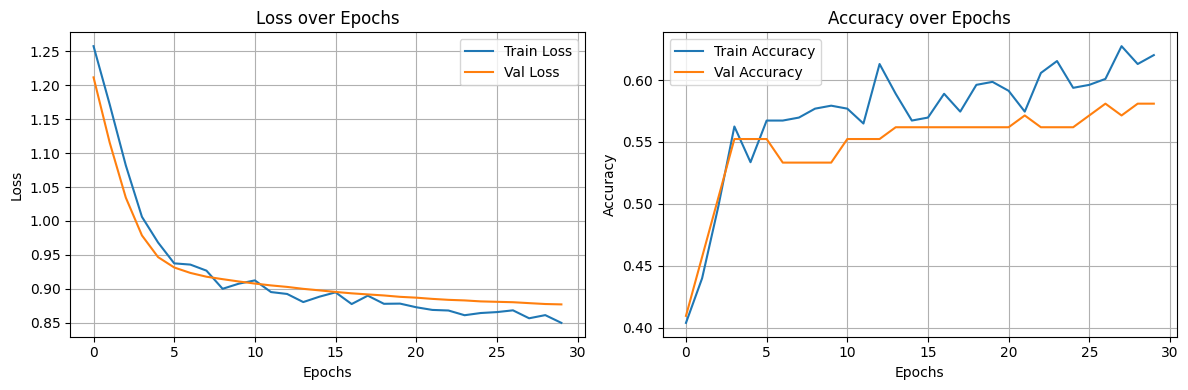

In [17]:
# 3. Train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=16,
    verbose=1
)

# 4. Plot training & validation metrics
plt.figure(figsize=(12, 4))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()